In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
truth = Table.read('/global/cfs/cdirs/desi/sv/vi/TruthTables/Blanc/LRG/desi-vi_LRG_tile80609_nightdeep_merged_all_21030.csv')
print(len(truth))

deep = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/blanc/v2/LRG/alltiles_LRGzinfo.fits'))
print(len(deep), len(np.unique(deep['TARGETID'])))

mask = deep['subset']=='deep'
print(np.sum(mask))
mask &= deep['TARGETS']=='QSO+LRG'
print(np.sum(mask))

deep = deep[mask]
print(len(deep), len(np.unique(deep['TARGETID'])))

_, idx1, idx2 = np.intersect1d(truth['TARGETID'], deep['TARGETID'], return_indices=True)
truth = truth[idx1]
deep = deep[idx2]
print(len(truth))
print(np.max(np.abs(truth['Redrock_z'] - deep['Z'])))

# Remove FIBERSTATUS!=0 fibers
mask = deep['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))

# Remove "no data" fibers
mask &= deep['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))

truth = truth[mask]
deep = deep[mask]

print(len(deep), len(np.unique(deep['TARGETID'])))

1789
79651 14100
14530
10113
10113 10113
1789
4.998714600867871e-05
FIBERSTATUS 1789 0 0.0
No data 1789 0 0.0
1789 1789


7011.713165283203


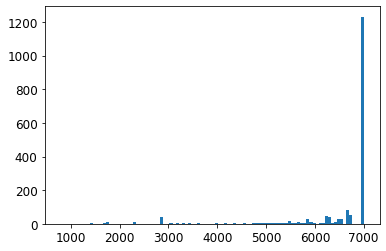

In [4]:
print(deep['R_DEPTH_EBVAIR'].max())
plt.hist(deep['R_DEPTH_EBVAIR'], 100);

In [5]:
# Require a minimum depth for the deep coadd
min_depth = 4000.
mask &= deep['R_DEPTH_EBVAIR']>min_depth
print(np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))

truth = truth[mask]
deep = deep[mask]

print(len(deep), len(np.unique(deep['TARGETID'])))

1684 105 0.941307993292342
1684 1684


In [6]:
truth[:1]

TARGETID,Redrock_z,best_z,best_quality,Redrock_spectype,best_spectype,all_VI_issues,all_VI_comments,merger_comment,N_VI,DELTACHI2,ZWARN,ZERR,TARGET_RA,TARGET_DEC,FIBER,FLUX_G,FLUX_R,FLUX_Z,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,EBV,TILEID
int64,float64,float64,float64,str6,str6,str3,str189,str41,int64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,int64
39627805352265275,0.3872,0.3872,4.0,GALAXY,GALAXY,--,--,none,5,14951.379413604736,0,1.972510639999562e-05,149.31702367611462,0.8448453052364348,666,2.8328052,15.289917,34.912575,1.525466,8.233623,18.800426,0.026536504,80609


In [7]:
lrg_opt = deep['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = deep['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = (deep['SV1_DESI_TARGET'] & 2**0>0)
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))

408
408
1684


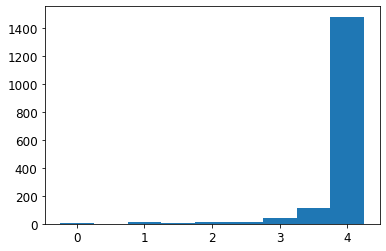

2.14%
6.12%


In [8]:
plt.hist(truth['best_quality'], bins=np.linspace(-0.25, 4.25, 10))
plt.show()

mask = truth['best_quality']<2.5
print('{:.2f}%'.format(np.sum(mask)/len(mask)*100))

mask = truth['best_quality']<3.5
print('{:.2f}%'.format(np.sum(mask)/len(mask)*100))

__Fraction of objects with bad VI quality__

In [9]:
mask_bad_vi = truth['best_quality'] < 2.5

mask = mask_bad_vi.copy()[lrg_sv]
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))

mask = mask_bad_vi.copy()[lrg_opt]
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))

mask = mask_bad_vi.copy()[lrg_ir]
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))

mask = mask_bad_vi.copy()[lrg_opt | lrg_ir]
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))

36 1648 2.14%
3 405 0.74%
2 406 0.49%
3 534 0.56%


__Fraction of objects whose VI z disagrees with redrock z__

In [10]:
zdiff_threshold = 0.0033
mask_zdiff = np.abs((deep['Z'] - truth['best_z'])/(1 + truth['best_z'])) > zdiff_threshold

mask = mask_zdiff.copy()
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))
mask &= mask_bad_vi  # find those that are also bad VI objects
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))
print()

mask = mask_zdiff.copy()[lrg_opt]
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))
mask &= mask_bad_vi[lrg_opt]  # find those that are also bad VI objects
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))
print()

mask = mask_zdiff.copy()[lrg_ir]
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))
mask &= mask_bad_vi[lrg_ir]  # find those that are also bad VI objects
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))
print()

59 1625 3.50%
22 1662 1.31%

3 405 0.74%
2 406 0.49%

5 403 1.23%
1 407 0.25%



In [11]:
mask = mask_zdiff.copy()
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))
mask |= mask_bad_vi  # add bad VI objects
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))
print()

mask = mask_zdiff.copy()[lrg_opt]
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))
mask |= mask_bad_vi[lrg_opt]  # add bad VI objects
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))
print()

mask = mask_zdiff.copy()[lrg_ir]
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))
mask |= mask_bad_vi[lrg_ir]  # add bad VI objects
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))
print()

59 1625 3.50%
73 1611 4.33%

3 405 0.74%
4 404 0.98%

5 403 1.23%
6 402 1.47%



__Increase the redshift tolerance__

In [12]:
zdiff_threshold = 0.01
mask_zdiff = np.abs((deep['Z'] - truth['best_z'])/(1 + truth['best_z'])) > zdiff_threshold

mask = mask_zdiff.copy()
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))

mask = mask_zdiff.copy()[lrg_opt]
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))

mask = mask_zdiff.copy()[lrg_ir]
print(np.sum(mask), np.sum(~mask), '{:.2f}%'.format(np.sum(mask)/len(mask)*100))

57 1627 3.38%
3 405 0.74%
4 404 0.98%


--------------
## Add sweep columns

In [13]:
# Snippets taken from desitarget

from desitarget.targets import encode_targetid

def decode_sweep_name(sweepname):
    sweepname = os.path.basename(sweepname)

    ramin, ramax = float(sweepname[6:9]), float(sweepname[14:17])
    decmin, decmax = float(sweepname[10:13]), float(sweepname[18:21])

    if sweepname[9] == 'm':
        decmin *= -1
    if sweepname[17] == 'm':
        decmax *= -1

    return [ramin, ramax, decmin, decmax]

def is_in_box(objs, radecbox, ra_col='RA', dec_col='DEC'):

    ramin, ramax, decmin, decmax = radecbox

    # ADM check for some common mistakes.
    if decmin < -90. or decmax > 90. or decmax <= decmin or ramax <= ramin:
        msg = "Strange input: [ramin, ramax, decmin, decmax] = {}".format(radecbox)
        log.critical(msg)
        raise ValueError(msg)

    ii = ((objs[ra_col] >= ramin) & (objs[ra_col] < ramax)
          & (objs[dec_col] >= decmin) & (objs[dec_col] < decmax))

    return ii

In [14]:
ls_columns = ['MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2']


# Ignore any possible north/south overlap

sweep_fn_list = []
for field in ['north', 'south']:
    sweep_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/{}/sweep/9.0'.format(field)
    sweep_fn_list += sorted(glob.glob(os.path.join(sweep_dir, '*.fits')))
sweep_fn_list = np.array(sweep_fn_list)

sweep_radec_list = [decode_sweep_name(sweep_fn) for sweep_fn in sweep_fn_list]
mask = np.array([np.any(is_in_box(deep, sweep_radec, ra_col='TARGET_RA', dec_col='TARGET_DEC')) for sweep_radec in sweep_radec_list])
print(np.sum(mask))
sweep_fn_list = sweep_fn_list[mask]

ls_stack = []
for sweep_fn in sweep_fn_list:
    ls = Table(fitsio.read(sweep_fn, columns=['OBJID', 'BRICKID', 'RELEASE']))
    targetid = encode_targetid(ls['OBJID'], ls['BRICKID'], ls['RELEASE'])
    idx = np.where(np.in1d(targetid, deep['TARGETID']))[0]
    if len(idx)==0:
        continue
    targetid = targetid[idx]
    ls = Table(fitsio.read(sweep_fn, rows=idx, columns=ls_columns))
    ls['TARGETID'] = targetid
    # pz_fn = sweep_fn.replace('sweep/9.0/', 'sweep/9.0-photo-z/').replace('.fits', '-pz.fits')
    # pz = Table(fitsio.read(pz_fn, rows=idx))
    # if '/south/sweep/' in sweep_fn:
    #     pz['field'] = 'south'
    # else:
    #     pz['field'] = 'north'
    # pz.remove_columns(['OBJID', 'BRICKID', 'RELEASE'])
    # ls = hstack([ls, pz])
    ls_stack.append(ls)
ls = vstack(ls_stack)
print(len(deep), len(ls))

# # This only works if the objects are unique
# _, idx1, idx2 = np.intersect1d(deep['TARGETID'], ls['TARGETID'], return_indices=True)
# print(len(deep), len(idx1), len(deep)-len(idx1))
# deep = deep[idx1]
# ls = ls[idx2]

deep = join(deep, ls, keys='TARGETID')

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    deep['gmag'] = 22.5 - 2.5*np.log10(deep['FLUX_G']/deep['MW_TRANSMISSION_G'])
    deep['rmag'] = 22.5 - 2.5*np.log10(deep['FLUX_R']/deep['MW_TRANSMISSION_R'])
    deep['zmag'] = 22.5 - 2.5*np.log10(deep['FLUX_Z']/deep['MW_TRANSMISSION_Z'])
    deep['w1mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W1']/deep['MW_TRANSMISSION_W1'])
    deep['w2mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W2']/deep['MW_TRANSMISSION_W2'])
    deep['gfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_G']/deep['MW_TRANSMISSION_G'])
    deep['rfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_R']/deep['MW_TRANSMISSION_R'])
    deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']/deep['MW_TRANSMISSION_Z'])

4
1684 1684


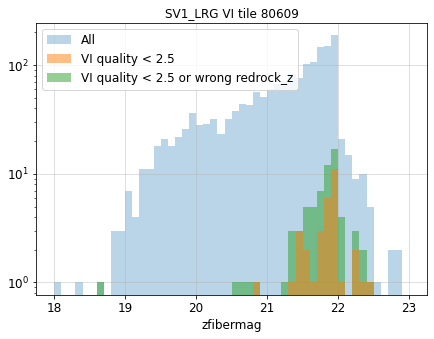

In [19]:
good_and_correct_z = (~mask_bad_vi) & (~mask_zdiff)

plt.figure(figsize=(7, 5))
plt.hist(deep['zfibermag'], bins=50, alpha=0.3, range=(18, 23), label='All', zorder=1, log=True)
plt.hist(deep['zfibermag'][mask_bad_vi], bins=50, alpha=0.5, range=(18, 23), label='VI quality < 2.5', zorder=3)
plt.hist(deep['zfibermag'][~good_and_correct_z], bins=50, alpha=0.5, range=(18, 23), label='VI quality < 2.5 or wrong redrock_z', zorder=2)
plt.xlabel('zfibermag')
plt.title('SV1_LRG VI tile 80609')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

In [20]:
np.all(deep['TARGETID']==truth['TARGETID'])

True

--------
## Add repeatability info

198699 14100
25260 1684


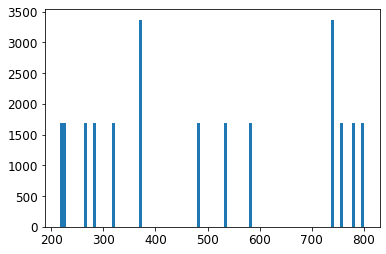

8420 1684


In [21]:
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/blanc/v2/LRG/alltiles_LRGzinfo_1exp.fits'))
print(len(zbest), len(np.unique(zbest['TARGETID'])))

mask = np.in1d(zbest['TARGETID'], deep['TARGETID'])
mask &= np.in1d(zbest['TILEID'], np.unique(deep['TILEID']))
zbest = zbest[mask]
print(len(zbest), len(np.unique(zbest['TARGETID'])))

plt.hist(zbest['R_DEPTH_EBVAIR'], 100)
plt.show()

mask = zbest['R_DEPTH_EBVAIR'] > 700
zbest = zbest[mask]
print(len(zbest), len(np.unique(zbest['TARGETID'])))

In [22]:
zbest = join(zbest, truth[['TARGETID', 'best_z', 'best_quality', 'best_spectype']], keys='TARGETID')
zbest = join(zbest, deep[['TARGETID', 'zfibermag']], keys='TARGETID')

In [39]:
mask_bad_vi = zbest['best_quality']<2.5
print(np.sum(mask_fail), np.sum(mask_bad_vi)/len(mask_bad_vi))

zdiff_threshold = 0.0033

# Deep z and VI z disagree
mask_zdiff = np.abs((zbest['Z_deep'] - zbest['best_z'])/(1 + zbest['best_z'])) > zdiff_threshold
print(np.sum(mask_zdiff), np.sum(mask_zdiff)/len(mask_zdiff))

# Not repeatable
mask_fail = np.abs((zbest['Z'] - zbest['Z_deep'])/(1 + zbest['Z_deep'])) > zdiff_threshold
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))

1022 0.021377672209026127
295 0.03503562945368171
1022 0.12137767220902612


In [43]:
print('{:.1f}% of the bad VI objects are also not repeatable'
      .format(np.sum(mask_bad_vi & mask_fail)/np.sum(mask_bad_vi)*100))

73.3% of the bad VI objects are also not repeatable


In [44]:
print('Adding bad VI objects increases the repeatability-based failure rate by {:.1f}%'
      .format(np.sum(mask_bad_vi | mask_fail)/np.sum(mask_fail)*100-100))

Adding bad VI objects increases the repeatability-based failure rate by 4.7%


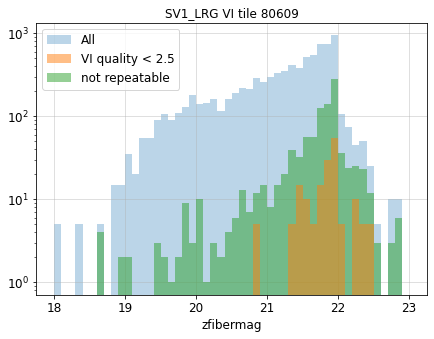

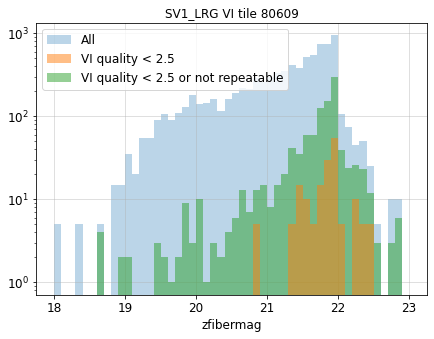

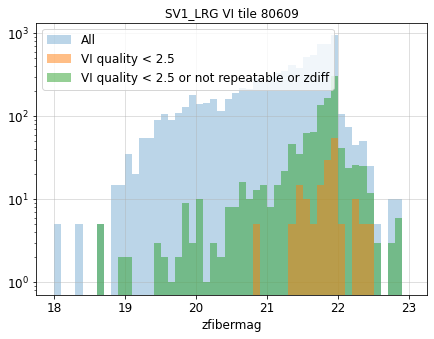

In [45]:
good_and_correct_z = (~mask_bad_vi) & (~mask_zdiff)

plt.figure(figsize=(7, 5))
plt.hist(zbest['zfibermag'], bins=50, alpha=0.3, range=(18, 23), label='All', zorder=1, log=True)
plt.hist(zbest['zfibermag'][mask_bad_vi], bins=50, alpha=0.5, range=(18, 23), label='VI quality < 2.5', zorder=3)
plt.hist(zbest['zfibermag'][mask_fail], bins=50, alpha=0.5, range=(18, 23), label='not repeatable', zorder=2)
plt.xlabel('zfibermag')
plt.title('SV1_LRG VI tile 80609')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(zbest['zfibermag'], bins=50, alpha=0.3, range=(18, 23), label='All', zorder=1, log=True)
plt.hist(zbest['zfibermag'][mask_bad_vi], bins=50, alpha=0.5, range=(18, 23), label='VI quality < 2.5', zorder=3)
plt.hist(zbest['zfibermag'][mask_bad_vi | mask_fail], bins=50, alpha=0.5, range=(18, 23), label='VI quality < 2.5 or not repeatable', zorder=2)
plt.xlabel('zfibermag')
plt.title('SV1_LRG VI tile 80609')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(zbest['zfibermag'], bins=50, alpha=0.3, range=(18, 23), label='All', zorder=1, log=True)
plt.hist(zbest['zfibermag'][mask_bad_vi], bins=50, alpha=0.5, range=(18, 23), label='VI quality < 2.5', zorder=3)
plt.hist(zbest['zfibermag'][mask_bad_vi | mask_fail | mask_zdiff], bins=50, alpha=0.5, range=(18, 23), label='VI quality < 2.5 or not repeatable or zdiff', zorder=2)
plt.xlabel('zfibermag')
plt.title('SV1_LRG VI tile 80609')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.show()